In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
from sklearn.model_selection import learning_curve as sk_learning_curve

import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
import plotly.express as px

In [2]:
import nltk
nltk.download('punkt_tab')

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/nasauramecca/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/nasauramecca/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/nasauramecca/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng') # New version for some NLTK releases

# Required for Tokenization and Lemmatization
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/nasauramecca/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/nasauramecca/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/nasauramecca/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/nasauramecca/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/nasauramecca/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/nasauramecca/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

: 

In [ ]:
import nltk
import os

# Ambil path dari log terminal lu tadi
data_path = '/Users/nasauramecca/nltk_data'

# Tambahkan ke daftar path NLTK
if data_path not in nltk.data.path:
    nltk.data.path.append(data_path)

# Verifikasi: Harus muncul list bahasa tanpa error
try:
    print("Data ditemukan:", nltk.corpus.stopwords.fileids()[:5])
except Exception as e:
    print("Waduh, masih gak nengok foldernya:", e)

Data ditemukan: ['albanian', 'arabic', 'azerbaijani', 'basque', 'belarusian']


: 

In [ ]:
def fungsi_cleaning_lu(text):
    import nltk
    from nltk.corpus import stopwords
    from nltk.tokenize import word_tokenize
    
    # Pastikan path ini juga ada di dalam fungsi kalau masih error
    if '/Users/nasauramecca/nltk_data' not in nltk.data.path:
        nltk.data.path.append('/Users/nasauramecca/nltk_data')
        
    # ... baru lanjut proses cleaning lu ...
    # stop_words = set(stopwords.words('indonesian'))
    return text

: 

Dataset Check

In [ ]:
data = pd.read_csv('/Users/nasauramecca/collage/smester 4/Natural language programming/aol/Datasetprojpowerbi.csv')
print(data.head())

                            Genre  \
0  Academic Support and Resources   
1  Academic Support and Resources   
2  Academic Support and Resources   
3  Academic Support and Resources   
4  Academic Support and Resources   

                                             Reports  Age   Gpa  Year  Count  \
0  The limited access to research databases and m...   27  2.18     2      1   
1  I'm having trouble finding the course material...   23  3.11     2      1   
2  It's frustrating to have limited access to res...   20  3.68     2      1   
3  I'm really struggling in one of my classes but...   20  1.30     2      1   
4   I am really struggling with understanding the...   26  2.50     2      1   

  Gender Nationality  
0      M       Egypt  
1      F       Egypt  
2      F       Egypt  
3      F       Egypt  
4      F       Egypt  


: 

In [ ]:
print(data.shape)

(1005, 8)


: 

In [ ]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Genre        1005 non-null   object 
 1   Reports      1005 non-null   object 
 2   Age          1005 non-null   int64  
 3   Gpa          1005 non-null   float64
 4   Year         1005 non-null   int64  
 5   Count        1005 non-null   int64  
 6   Gender       1005 non-null   object 
 7   Nationality  1005 non-null   object 
dtypes: float64(1), int64(3), object(4)
memory usage: 62.9+ KB
None


: 

/var/folders/5h/d2499f1527bgm332w8qv3q380000gn/T/ipykernel_25646/2536947719.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.values, y=class_counts.index, palette='viridis')


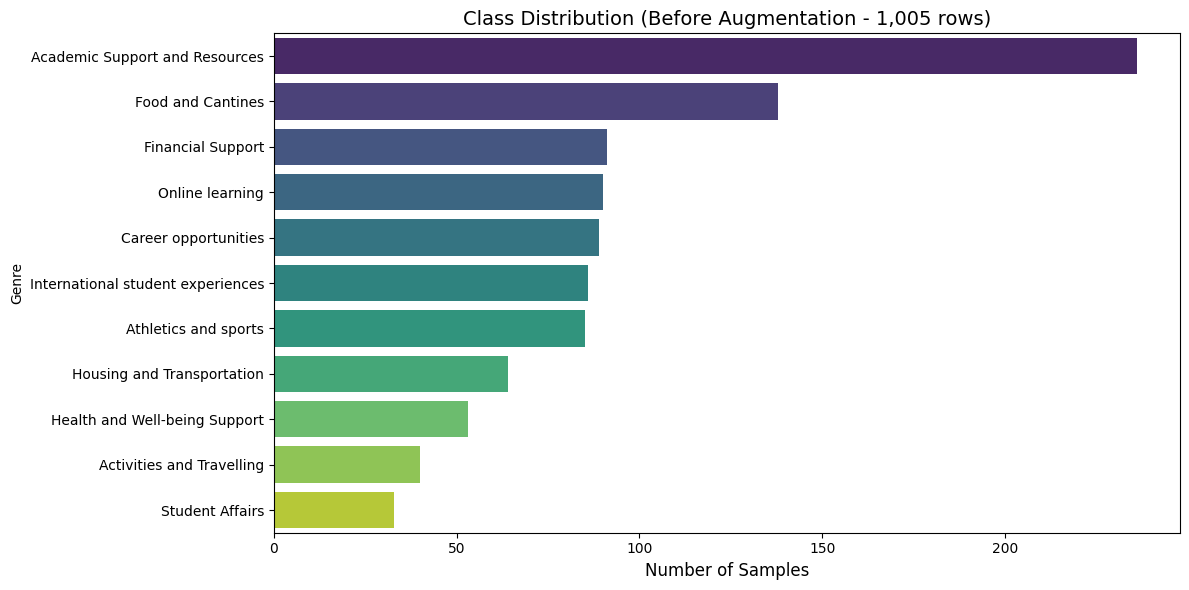

: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribusi kelas sebelum augmentasi (dataset asli 1.005 rows)
plt.figure(figsize=(12, 6))
class_counts = data['Genre'].value_counts()
sns.barplot(x=class_counts.values, y=class_counts.index, palette='viridis')
plt.xlabel('Number of Samples', fontsize=12)
plt.title('Class Distribution (Before Augmentation - 1,005 rows)', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
#Dropping unused columns

cols_to_drop = ['Age', 'Gpa', 'Year', 'Count', 'Gender', 'Nationality']

data = data.drop(columns=(cols_to_drop))

data.head()

,Genre,Reports
0,Academic Support and Resources,The limited access to research databases and m...
1,Academic Support and Resources,I'm having trouble finding the course material...
2,Academic Support and Resources,It's frustrating to have limited access to res...
3,Academic Support and Resources,I'm really struggling in one of my classes but...
4,Academic Support and Resources,I am really struggling with understanding the...


: 

In [ ]:
x = data['Reports']
y = data['Genre']

# Split the data (80% training, 20% testing)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)


: 

EDA

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Genre    1005 non-null   object
 1   Reports  1005 non-null   object
dtypes: object(2)
memory usage: 15.8+ KB


: 

In [ ]:
data.describe(include=object)

,Genre,Reports
count,1005,1005
unique,11,1001
top,Academic Support and Resources,The limited access to research databases and m...
freq,236,2


: 

In [ ]:
missing_summary = pd.DataFrame({
    'Missing_Count': data.isnull().sum(),
    'Missing_Percentage' : (data.isnull().sum().mean() *100).round(2)
})

missing_summary

,Missing_Count,Missing_Percentage
Genre,0,0.0
Reports,0,0.0


: 

Preprocessing

In [ ]:
#Lemmatizing

lemmatizer = WordNetLemmatizer()

def get_label(tag):
    if tag.startswith('j'):
        return 'a'
    elif tag.startswith('r') or tag.startswith('v') or tag.startswith('n'):
        return tag[0]
    else:
        return 'a'
    
def lemmatizing(word_list):
    lemma_list = []
    tagged = pos_tag(word_list)

    for word, tag in tagged:
        label = get_label(tag.lower())
        if label:
            result = lemmatizer.lemmatize(word, label)
            lemma_list.append(result)
        else:
            result = lemmatizer.lemmatize(word)
            lemma_list.append(result)
            
    return lemma_list

def preprocessing(sentence):
    eng_stopwords = set(stopwords.words('english'))
    punctuations = set(string.punctuation)

    sentence = sentence.lower()

    word_list = word_tokenize(sentence)

    filtered = [
        token for token in word_list
        if token not in eng_stopwords
        and token not in punctuations
        and token.isalpha()
    ]

    return lemmatizing(filtered)


: 

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

: 

In [ ]:
models = {
    "Naive Bayes": Pipeline([
        ('tfidf', TfidfVectorizer(
            tokenizer=preprocessing,
            ngram_range=(1,2),
            min_df=3,
            max_df=0.9
        )),
        ('clf', MultinomialNB(alpha=0.1))
    ]),

    "Logistic Regression": Pipeline([
        ('tfidf', TfidfVectorizer(
            tokenizer=preprocessing,
            ngram_range=(1,2),
            min_df=3,
            max_df=0.9
        )),
        ('clf', LogisticRegression(
            C=5,
            max_iter=5000,
            class_weight='balanced'
        ))
    ]),

    "Linear SVC": Pipeline([
        ('tfidf', TfidfVectorizer(
            tokenizer=preprocessing,
            ngram_range=(1,2),
            min_df=3,
            max_df=0.9
        )),
        ('clf', LinearSVC(
            C=3,
            max_iter=5000,
            class_weight='balanced'
        ))
    ]),

    "Random Forest": Pipeline([
        ('tfidf', TfidfVectorizer(
            tokenizer=preprocessing,
            ngram_range=(1,2),
            min_df=3,
            max_df=0.9
        )),
        ('clf', RandomForestClassifier(
            n_estimators=300,
            max_depth=20,
            min_samples_leaf=3,
            random_state=42
        ))
    ])
}

: 

In [ ]:
print(type(x_train))
print(x_train.head())

<class 'pandas.core.series.Series'>
607    17. "I think it would be helpful if the univer...
68     Limited access to technology and software is m...
378    The university should offer more support to no...
349    The university should provide more guidance an...
722     I feel like online classes aren't preparing m...
Name: Reports, dtype: object


: 

In [ ]:
for name, model in models.items():
    print(f"\n{name}")

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    print(classification_report(y_test, y_pred))

    scores = cross_val_score(
        model,
        x_train,
        y_train,
        cv=5,
        scoring='f1_macro'
    )

    print("CV Macro F1:", scores.mean())


Naive Bayes


/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


                                   precision    recall  f1-score   support

   Academic Support and Resources       0.90      0.98      0.94        47
        Activities and Travelling       1.00      0.88      0.93         8
             Athletics and sports       0.94      0.88      0.91        17
             Career opportunities       1.00      1.00      1.00        18
                Financial Support       1.00      1.00      1.00        18
                Food and Cantines       1.00      1.00      1.00        27
    Health and Well-being Support       0.83      0.91      0.87        11
       Housing and Transportation       0.92      0.85      0.88        13
International student experiences       0.94      1.00      0.97        17
                  Online learning       0.94      0.83      0.88        18
                  Student Affairs       1.00      0.86      0.92         7

                         accuracy                           0.95       201
                       

/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/skl

CV Macro F1: 0.8892047197217192

Logistic Regression


...

/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


                                   precision    recall  f1-score   support

   Academic Support and Resources       0.81      1.00      0.90        47
        Activities and Travelling       1.00      0.38      0.55         8
             Athletics and sports       1.00      0.88      0.94        17
             Career opportunities       0.95      1.00      0.97        18
                Financial Support       0.94      0.83      0.88        18
                Food and Cantines       0.93      1.00      0.96        27
    Health and Well-being Support       0.91      0.91      0.91        11
       Housing and Transportation       0.85      0.85      0.85        13
International student experiences       1.00      0.88      0.94        17
                  Online learning       1.00      0.89      0.94        18
                  Student Affairs       1.00      0.86      0.92         7

                         accuracy                           0.91       201
                       

/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/skl

CV Macro F1: 0.803569933472893


: 

/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/skl

Best Model: Logistic Regression
Best CV Macro F1: 0.920876651625085


/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


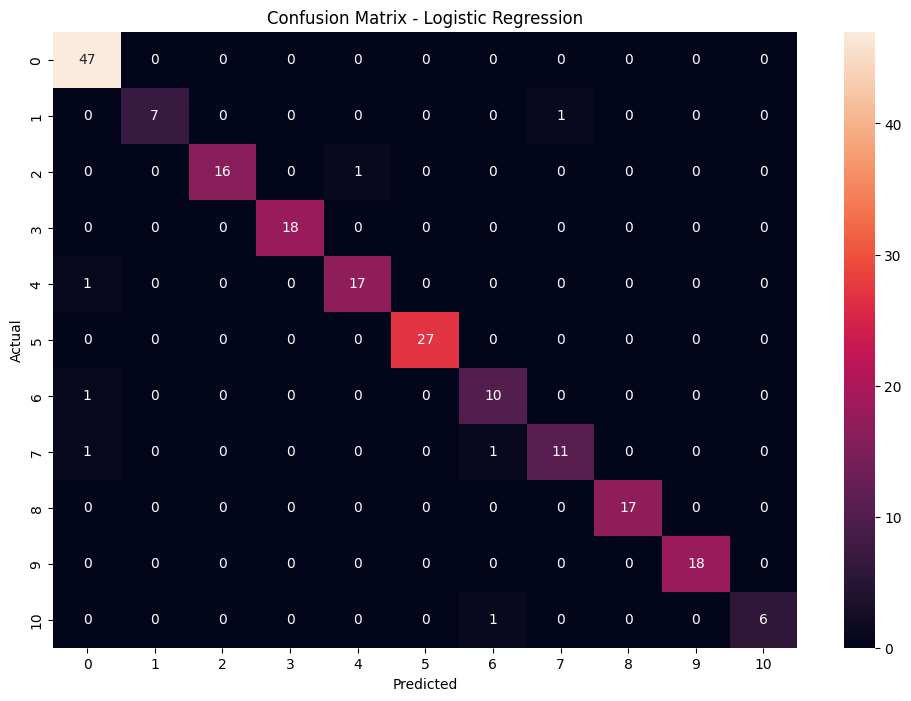

: 

In [ ]:
results = {}

for name, model in models.items():
    scores = cross_val_score(
        model,
        x_train,
        y_train,
        cv=5,
        scoring='f1_macro'
    )

    results[name] = scores.mean()

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("Best Model:", best_model_name)
print("Best CV Macro F1:", results[best_model_name])

best_model.fit(x_train, y_train)
y_pred = best_model.predict(x_test)

plt.figure(figsize=(12,8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

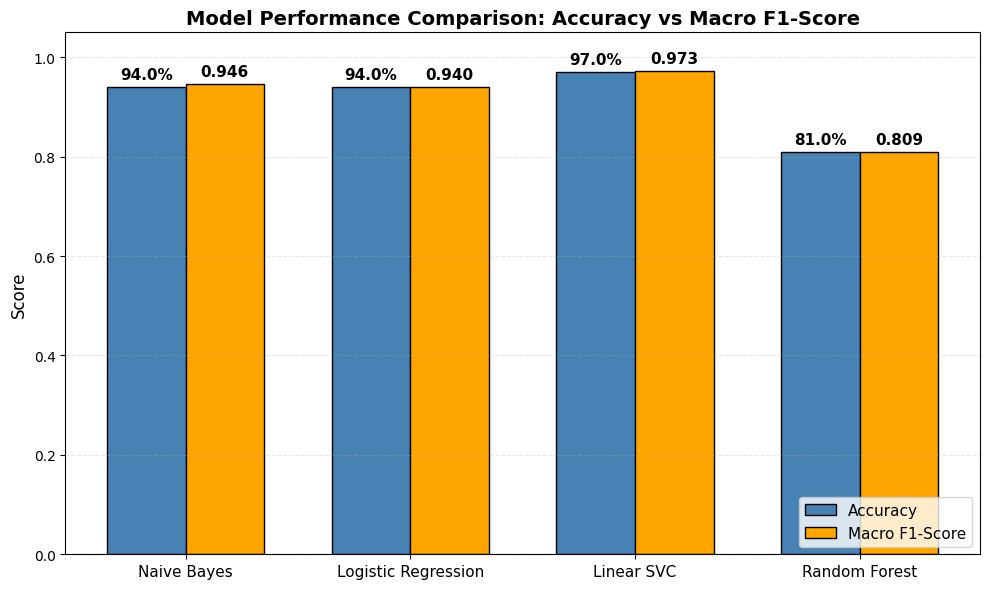

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data akurasi dari hasil training kalian
models = ['Naive Bayes', 'Logistic Regression', 'Linear SVC', 'Random Forest']
accuracy = [0.94, 0.94, 0.97, 0.81]  # Test accuracy dari output kode
f1_score = [0.9456, 0.9398, 0.9730, 0.8092]  # Macro F1 dari output

# Setup plot
fig, ax = plt.subplots(figsize=(10, 6))

# Bar chart
x = np.arange(len(models))
width = 0.35
bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, f1_score, width, label='Macro F1-Score', color='orange', edgecolor='black')

# Tambahkan label nilai di atas bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Labels dan title
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison: Accuracy vs Macro F1-Score', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [ ]:
# Gunakan Logistic Regression untuk prediksi teks baru dalam bahasa Inggris
logistic_model = models["Logistic Regression"]
logistic_model.fit(x_train, y_train)

def predict_genre(text, model=logistic_model):
    return model.predict([text])[0]

english_samples = [
    "The indoor basketball court is so slippery and dusty. It’s actually dangerous; I almost twisted my ankle yesterday",
    "The gym is way too small for the number of students. You have to queue for 30 minutes just to use the bench press.",
    "sports",
    "I’m struggling to keep up with my training routine because the gym equipment is constantly broken. I wish the maintenance team was more responsive to these repairs."
    
]

for sample in english_samples:
    print("Input:", sample)
    print("Predicted Genre:", predict_genre(sample))
    print()

/opt/homebrew/Caskroom/miniconda/base/envs/ai_gacor/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Input: The indoor basketball court is so slippery and dusty. It’s actually dangerous; I almost twisted my ankle yesterday
Predicted Genre: Academic Support and Resources

Input: The gym is way too small for the number of students. You have to queue for 30 minutes just to use the bench press.
Predicted Genre: Financial Support

Input: sports
Predicted Genre: Athletics and sports

Input: I’m struggling to keep up with my training routine because the gym equipment is constantly broken. I wish the maintenance team was more responsive to these repairs.
Predicted Genre: Financial Support



: 